# Starfysh tutorial for sample integration

**Azizi Lab**

Siyu He, Yinuo Jin, Lingting Shi


This tutorial provides an example of using Starfysh to characterize common *spatial hubs* through integrative spatial deconvolution from multiple VisiumHD samples. 

In [ ]:
# how to generate a dependency requirements.txt file for this current environment
! pip freeze > requirements.txt


In [1]:
! pip list

Package                       Version
----------------------------- -----------
affine                        2.4.0
aiobotocore                   2.5.4
aiohappyeyeballs              2.4.3
aiohttp                       3.11.2
aioitertools                  0.12.0
aiosignal                     1.3.1
alabaster                     0.7.16
anndata                       0.10.9
anndata2ri                    1.3.2
annotated-types               0.7.0
anyio                         4.6.2
appnope                       0.1.2
argon2-cffi                   21.3.0
argon2-cffi-bindings          21.2.0
array_api_compat              1.9.1
asciitree                     0.3.3
asttokens                     2.0.5
async-lru                     2.0.4
async-timeout                 5.0.1
attrs                         24.2.0
babel                         2.16.0
backcall                      0.2.0
beautifulsoup4                4.12.3
bleach                        4.1.0
botocore                      1.31.17
Brotli   

In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip3 install scanpy
    from google.colab import drive
    drive.mount('/content/drive')
    import sys
    sys.path.append('/content/drive/MyDrive/SpatialModelProject/model_test_colab/')

import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import torch

import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import rcParams

font_list = []
fpaths = matplotlib.font_manager.findSystemFonts()
for i in fpaths:
    try:
        f = matplotlib.font_manager.get_font(i)
        font_list.append(f.family_name)
    except RuntimeError:
        pass

font_list = set(font_list)
plot_font = 'Helvetica' if 'Helvetica' in font_list else 'FreeSans'

rcParams['font.family'] = plot_font
rcParams.update({'font.size': 10})
rcParams.update({'figure.dpi': 300})
rcParams.update({'figure.figsize': (3,3)})
rcParams.update({'savefig.dpi': 500})

import warnings
warnings.filterwarnings('ignore')

## Load Starfysh

from starfysh import (AA, utils, plot_utils, post_analysis, utils_integrate)
from starfysh import starfysh as sf_model
#!pip install -U PhenoGraph

### (1), load datasets & marker genes

File input:

- Spatial transcriptomics
    - Count matrices: list of `adata`s

Starfysh is built upon scanpy and Anndata. The common ST/Visium data sample folder consists a expression count file (usually `filtered_feature_bc_matrix.h5`), and a subdirectory with corresponding H&E image and spatial information, as provided by Visium platform.

For ST data that doesn't follow the consensus data struction (e.g. missing `filtered_feature_bc_matrix.h5`), please ensure that a `.h5ad` count matrix exists in the data directory.

Example directory structure:

```
├── ../data

    ├── SLV17:
        ├──binned_output:
            \__square_002um
                square_008um
                square_0016um


        ├── spatial:
            \__ scalefactors_json.json
                tissue_hires_image.png
                tissue_positions_list.csv
                ...  
```

Create meta info. for samples

In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import json
import matplotlib.pyplot as plt

min_genes_values = {
    'SLV11': 150,
    'SLV12': 50,
    'SLV13': 50,
    'SLV14': 50,
    'SLV15': 50,
    'SLV16': 150,
    'SLV17': 50,
    'SLV18': 150,# Change as needed for each sample
}



def load_visium_data(base_path, sample_id, min_genes=50, n_top_genes=2000, mt_thld=20):
    """
    Load and process Visium spatial data
    
    Parameters:
    -----------
    base_path : str
        Path to the base directory containing data
    sample_id : str
        ID of the sample to process
    min_genes : int, optional
        Minimum number of genes for filtering (default: 50)
    n_top_genes : int, optional
        Number of top variable genes to select (default: 2000)
    mt_thld : int, optional
        Threshold for mitochondrial gene percentage (default: 20)
    
    Returns:
    --------
    tuple
        (adata, adata_norm, img_metadata)
    """
    # Read tissue positions
    tissue_positions = pd.read_parquet(os.path.join(
        base_path,
        sample_id,
        'binned_outputs',
        'square_016um',
        'spatial',
        'tissue_positions.parquet'
    ))

    # Read gene expression data
    adata = sc.read_10x_h5(os.path.join(
        base_path,
        sample_id,
        'binned_outputs',
        'square_016um',
        'filtered_feature_bc_matrix.h5'
    ))

    # Match positions with expression data
    matched_positions = tissue_positions[tissue_positions['barcode'].isin(adata.obs.index)]
    matched_positions = matched_positions.set_index('barcode')
    matched_positions = matched_positions.loc[adata.obs.index]

    # Add spatial coordinates to adata
    adata.obs[['in_tissue','array_row','array_col','pxl_row_in_fullres', 'pxl_col_in_fullres']] = matched_positions[
        ['in_tissue','array_row','array_col','pxl_row_in_fullres', 'pxl_col_in_fullres']]

    # Make var names unique and add sample ID
    adata.var_names_make_unique()
    adata.obs['sample'] = sample_id

    # Clean up var names if needed
    if '_index' in adata.var.columns:
        adata.var_names = adata.var['_index']
        adata.var_names.name = 'Genes'
        adata.var.drop('_index', axis=1, inplace=True)

    # Calculate QC metrics
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

    # Basic filtering
    sc.pp.filter_cells(adata, min_counts=min_genes)
    #sc.pp.filter_genes(adata, min_cells=100)
    

    # Create copy for normalized version
    adata_raw = adata.copy()

    # Additional filtering and normalization
    adata.var['mt'] = np.logical_or(
        adata.var_names.str.startswith('MT-'),
        adata.var_names.str.startswith('mt-'))
    adata.var['rb'] = (
        adata.var_names.str.startswith('RP-') |
        adata.var_names.str.startswith('rp-'))

    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
    mask_cell = adata.obs['pct_counts_mt'] < mt_thld
    mask_gene = np.logical_and(~adata.var['mt'], ~adata.var['rb'])

    adata = adata[mask_cell, mask_gene]

    # Normalize and log transform
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)

    # Find variable genes
    sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=n_top_genes, inplace=True)

    # Filter raw data to match normalized data
    adata_raw = adata_raw[adata.obs_names, adata.var_names]
    adata_raw.var['highly_variable'] = adata.var['highly_variable']
    adata_raw.obs = adata.obs

    # Prepare image metadata
    # Load scale factors
    with open(os.path.join(base_path, sample_id, 'binned_outputs/square_016um/spatial/scalefactors_json.json'), 'r') as f:
        scalefactor = json.load(f)

    # Load high-res image
    img = plt.imread(os.path.join(base_path, sample_id, 'spatial/tissue_hires_image.png'))

    # Prepare map info
    map_info = matched_positions[['in_tissue','array_row','array_col','pxl_row_in_fullres', 'pxl_col_in_fullres']]
    map_info['imagerow'] = pd.to_numeric(map_info['pxl_row_in_fullres'], errors='coerce').fillna(0).astype(int)
    map_info['imagecol'] = pd.to_numeric(map_info['pxl_col_in_fullres'], errors='coerce').fillna(0).astype(int)
    map_info = map_info[['array_row','array_col','imagerow','imagecol']]

    img_metadata = {
        'img': img,
        'map_info': map_info,
        'scalefactor': scalefactor
    }

    return adata_raw, adata, img_metadata






In [ ]:
meta_info = [
    ['SLV11', 'C159', 'Antrum', 'Severe'],
    ['SLV12', 'C162', 'Rectum', 'Mild'],
    ['SLV13', 'C98', 'Stomach_Body', 'Severe'],
    ['SLV14', 'C159', 'Rectum', 'Severe'],
    ['SLV15', 'C179', 'Antrum', 'Mild'],
    ['SLV16', 'C179', 'Ascending_Colon', 'Mild'],
    ['SLV17', 'ND001', 'Ascending_Colon', 'ND'],
    ['SLV18', 'C162', 'Stomach', 'Mild']
]
meta_info = pd.DataFrame(meta_info,columns=['sample','patient','tissue_type','grade'])
base_path = '/Users/lingting/Documents/GVHD_project/visiumHD/data/'

# Load data
adata_all = []
adata_normed_all = []
img_metadata_all = {}

for sample_id in meta_info['sample']:
    print(sample_id)
    adata, adata_normed, img_metadata = load_visium_data(base_path, sample_id, min_genes=min_genes_values.get(sample_id, 50), n_top_genes=2000, mt_thld=20 )  # root data directory


    adata_normed = adata_normed[adata_normed.obs.index.isin(adata.obs.index)]
    adata_all.append(adata)
    
    
    
    adata.obs['patient']=meta_info['patient'][list(meta_info['sample']).index(sample_id)]
    adata.obs['sample_type']=meta_info['tissue_type'][list(meta_info['sample']).index(sample_id)]
    adata.obs['grade']=meta_info['grade'][list(meta_info['sample']).index(sample_id)]
    adata.obs_names  = adata.obs_names+'-'+sample_id

    adata_normed.obs_names  = adata_normed.obs_names+'-'+sample_id

    adata_normed.obs['patient']=adata.obs['patient']
    adata_normed.obs['sample_type']=adata.obs['sample_type']
    adata_normed.obs['grade']=adata.obs['grade']
    adata_normed_all.append(adata_normed)

    img_metadata['map_info'].index = img_metadata['map_info'].index+'-'+sample_id
    map_info = img_metadata['map_info']
    map_info = map_info[map_info.index.isin(adata.obs.index)]
    img_metadata['map_info'] = map_info
    
    img_metadata_all[sample_id] = img_metadata 
    

# Save concat data
adata_all = anndata.concat(adata_all)
adata_normed_all = anndata.concat(adata_normed_all)

sc.pp.highly_variable_genes(adata_normed_all)
adata_all.uns = adata_normed_all.uns
adata_all.var = adata_normed_all.var

adata_all.write(os.path.join(base_path, 'adata_integrate.h5ad'))
adata_normed_all.write(os.path.join(base_path, 'adata_normed_integrate.h5ad'))

SLV11


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


SLV12
SLV13
SLV14
SLV15
SLV16
SLV17
SLV18


... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sample_type' as categorical
... storing 'grade' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'sample_type' as categorical
... storing 'grade' as categorical


In [2]:

base_path = '/Users/lingting/Documents/GVHD_project/visiumHD/data/'
#adata_all= anndata.read(os.path.join(base_path, 'adata_integrate.h5ad'))
#adata_normed_all = anndata.read(os.path.join(base_path, 'adata_normed_integrate.h5ad'))

In [ ]:
adata_all

In [4]:
# Count cells per sample ID
sample_counts = adata_all.obs['sample'].value_counts()

# Display the counts
print(sample_counts)

# Optional: Summary statistics
print("\nTotal number of samples:", len(sample_counts))
print("Average cells per sample:", sample_counts.mean())
print("Min cells per sample:", sample_counts.min())
print("Max cells per sample:", sample_counts.max())

sample
SLV13    44252
SLV11    42309
SLV15    30843
SLV14    30206
SLV18    26065
SLV17    21271
SLV16    21228
SLV12    16708
Name: count, dtype: int64

Total number of samples: 8
Average cells per sample: 29110.25
Min cells per sample: 16708
Max cells per sample: 44252


In [6]:
sig_file_name = '/Users/lingting/Documents/GVHD_project/Spatial data/data/GVHD_spatial_signature_v8_major_curated_unique_epi_tcells_subset_Transition_EPI_REFINE.csv'
gene_sig = pd.read_csv(sig_file_name, encoding='latin1')
gene_sig = utils.filter_gene_sig(gene_sig, adata_all.to_df())
gene_sig.head()

,Plasma cells,Myeloid,Fibroblast,B cells,NK cells,Instestinal Epithelial cells,Enterocyte,Stomach Epithelial cells,Stomach Stem cells,Endothelial cells,...,CD4+ Effector T cells,CD4+ Central Memory T cells,CD8+ Cytotoxic Unconventional T cells,CD8+ Proliferating T cells,CD4+ Regulatory T cells,CD8+ Homeostatic Unconventional T cells,CD8+ Tissue Resident Memory T cells,CD8+ Transitioning Resident T cells,Intestine Epithelial Stem cells,Stomach Body Epithelial cells
0,DERL3,CD14,ACTA2,CD19,NCR1,EPCAM,ANPEP,CLDN18,LGR5,PECAM1,...,CD3E,CD3E,CD3E,CD3E,CD3E,CD3E,CD3E,CD3E,LGR5,LIPF
1,DNAJB9,CD163,C1S,CR2,NCAM1,TFF3,PRAP1,PGC,MUC6,FLT1,...,CD3G,CD3G,CD3G,CD3G,CD3G,CD3G,CD3G,CD3G,ASCL2,PGA5
2,FCRL5,AIF1,COL1A1,IGHD,KRT86,C10orf99,RBP2,PSCA,FMOD,HSPG2,...,CD3D,CD3D,CD3D,CD3D,CD3D,CD3D,CD3D,CD3D,SMOC2,CHIA
3,LINC02362,C1QA,COL1A2,MS4A1,SH2D1B,CKB,FABP2,CTSE,FUT9,RAMP3,...,CD40LG,CD4,GZMA,MKI67,CD4,KIR2DL4,CD8A,CD8A,MSI1,ATP4A
4,MZB1,C1QB,COL3A1,PAX5,TXK,CEACAM5,SMIM24,ANXA10,GP2,RAMP2,...,CD4,TNFRSF4,GNLY,GTSE1,FOXP3,HOPX,CD8B,CD8B,RARRES2,ATP4B


In [7]:
img_metadata_all

{'SLV11': {'img': array([[[0.9490196 , 0.92941177, 0.9372549 ],
          [0.94509804, 0.93333334, 0.9372549 ],
          [0.94509804, 0.93333334, 0.9411765 ],
          ...,
          [0.9529412 , 0.9372549 , 0.9411765 ],
          [0.9529412 , 0.93333334, 0.9411765 ],
          [0.9529412 , 0.93333334, 0.9411765 ]],
  
         [[0.94509804, 0.92941177, 0.9372549 ],
          [0.94509804, 0.93333334, 0.9372549 ],
          [0.94509804, 0.93333334, 0.9411765 ],
          ...,
          [0.9529412 , 0.93333334, 0.9411765 ],
          [0.9529412 , 0.93333334, 0.9372549 ],
          [0.9529412 , 0.93333334, 0.9372549 ]],
  
         [[0.94509804, 0.93333334, 0.9411765 ],
          [0.94509804, 0.93333334, 0.9411765 ],
          [0.94509804, 0.93333334, 0.9411765 ],
          ...,
          [0.9529412 , 0.93333334, 0.9411765 ],
          [0.9529412 , 0.93333334, 0.9372549 ],
          [0.9529412 , 0.9372549 , 0.9372549 ]],
  
         ...,
  
         [[0.95686275, 0.9372549 , 0.94509804]

### (2). Preprocessing

Starfysh calcualates cell-type proportion scores for each spot per sample given the annotated signatures (per cell type) as the model's prior

Each spot will be ranked (`anchors_df`) based on the prior, which represents the rough estimation of the given cell-type's enrichment

In [130]:
# Load saved concat data
#adata_all = sc.read_h5ad(os.path.join(data_path, 'adata_integrate.h5ad'))
#adata_normed_all = sc.read_h5ad(os.path.join(data_path, 'adata_normed_integrate.h5ad'))

In [131]:
adata

AnnData object with n_obs × n_vars = 26065 × 18074
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'patient', 'sample_type', 'grade'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'

In [132]:
adata_normed

AnnData object with n_obs × n_vars = 26065 × 18074
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'patient', 'sample_type', 'grade'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'rb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [133]:
gene_sig

,Plasma cells,Myeloid,Fibroblast,B cells,NK cells,Instestinal_Epithelial cells,Enterocyte,Stomach_epithelial_cells,Stomach_stem_cells,Endothelial cell,...,CD4+ Effector T cells,CD4+ Central Memory T cells,CD8+ Cytotoxic Unconventional T cells,CD8+ Proliferating T cells,CD4+ Regulatory T cells,CD8+ Homeostatic Unconventional T cells,CD8+ Tissue Resident Memory T cells,CD8+ Transitioning Resident T cells,Intestine_Epithelial Stem cell,Stomach_Body_Epithelial_cells
0,DERL3,CD14,ACTA2,CD19,NCR1,EPCAM,ANPEP,CLDN18,LGR5,PECAM1,...,CD3E,CD3E,CD3E,CD3E,CD3E,CD3E,CD3E,CD3E,LGR5,LIPF
1,DNAJB9,CD163,C1S,CR2,NCAM1,TFF3,PRAP1,PGC,MUC6,FLT1,...,CD3G,CD3G,CD3G,CD3G,CD3G,CD3G,CD3G,CD3G,ASCL2,PGA5
2,FCRL5,AIF1,COL1A1,IGHD,KRT86,C10orf99,RBP2,PSCA,FMOD,HSPG2,...,CD3D,CD3D,CD3D,CD3D,CD3D,CD3D,CD3D,CD3D,SMOC2,CHIA
3,LINC02362,C1QA,COL1A2,MS4A1,SH2D1B,CKB,FABP2,CTSE,FUT9,RAMP3,...,CD40LG,CD4,GZMA,MKI67,CD4,KIR2DL4,CD8A,CD8A,MSI1,ATP4A
4,MZB1,C1QB,COL3A1,PAX5,TXK,CEACAM5,SMIM24,ANXA10,GP2,RAMP2,...,CD4,TNFRSF4,GNLY,GTSE1,FOXP3,HOPX,CD8B,CD8B,RARRES2,ATP4B
5,IGLC1,C1QC,COL6A1,BANK1,KIR2DL1,AXIN2,CCL25,TFF2,MSMB,PLVAP,...,IL7R,CD40LG,CD7,TOP2A,TNFRSF4,TMIGD2,TMIGD2,TMIGD2,SOX9,ALDOB
6,TNFRSF17,CSF1R,COL6A2,VPREB3,KIR2DL3,PLA2G2A,CLDN15,VSIG1,MUC5AC,SLCO2A1,...,KLRB1,CCR4,FCER1G,CD8A,CTLA4,CD7,CD248,CD248,CENPM,CCKBR
7,TXNDC5,IGSF6,CXCL14,NaN,KIR3DL2,PRAC1,ALD08,TFF1,TFF1,SOX18,...,SESN1,CD28,NKG7,CD8B,TBC1D4,KLRC2,ITGA1,ITGA1,EPHB2,CPA2
8,SDC1,MERTK,CYGB,NaN,KIR3DL1,MUC4,REEP6,MUC5AC,PGC,VWF,...,CCR6,IL7R,CD247,LAG3,TIGIT,CD160,ITGAE,ITGAE,OLFM4,DNER
9,EAF2,MS4A6A,DCN,NaN,CD160,SNORC,KHK,CA9,TFF2,NaN,...,TNF,TCF7,KIR2DL4,HAVCR2,IL2RA,ITGA1,CD101,CD101,NaN,DRD5


In [134]:
from starfysh.AA import ArchetypalAnalysis
import scanpy as sc

In [135]:
def assign_archetypes(anchor_df, r=30):
    """
    Assign best 1-1 mapping of archetype community to its closest anchor community (cell-type specific anchor spots)
    Criteria: choose the top cell type in which its anchors belongs to the top r neighbors to the given archetype

    Parameters
    ----------
    anchor_df : pd.DataFrame
        Dataframe of anchor spot indices

`       r : int
        Resolution parameter to threshold archetype - anchor mapping

    Returns
    -------
    map_df : pd.DataFrame
        DataFrame of overlapping spot ratio of each anchor `i` to archetype `j`

    map_dict : dict
        Dictionary of cell type -> mapped archetype
    """
    assert aa_model.arche_df is not None, "Please compute archetypes & assign nearest-neighbors first!"

    n_nbrs, n_archetypes = aa_model.arche_df.shape # number of archetypal spots for each archtype, number of archetypes
    x_concat = np.vstack([aa_model.count, aa_model.archetype])
    anchor_nbrs = anchor_df.values
    archetypal_nbrs = aa_model._get_knns(x_concat, n_nbrs=r, indices=aa_model.n_spots+aa_model.major_idx).T  # r-nearest nbrs to each archetype

    
    
    print(archetypal_nbrs.shape)
    overlaps = np.array(
        [
            [
                len(np.intersect1d(anchor_nbrs[:, i], archetypal_nbrs[:, j]))
                for j in range(archetypal_nbrs.shape[1])
            ]
            for i in range(anchor_nbrs.shape[1])
        ]
    )
    overlaps_df = pd.DataFrame(overlaps, index=anchor_df.columns, columns=aa_model.arche_df.columns)
    arche_argmaxs = overlaps.argmax(0)
    
    distance_df = pd.DataFrame(np.zeros([anchor_df.shape[1],
                                         aa_model.arche_df.shape[1]]), 
                               index=anchor_df.columns, 
                               columns=aa_model.arche_df.columns
                              )
    for i in range(distance_df.shape[0]):
        for j in range(distance_df.shape[1]):
            dist_tmp = 0
            for kk in anchor_df.iloc[:,i]:
                dist_tmp += np.linalg.norm(aa_model.count[kk,:] - 
                                           aa_model.archetype[j,:]
                                          )
            
            distance_df.iloc[i,j] = dist_tmp
    
    map_dict = {}
    for k in range(overlaps.shape[0]):
        list_ = np.argsort(overlaps[k])[::-1]
        for i in list_:
            if (np.argsort(overlaps[:,i])[::-1][0]==k):
                if ((overlaps[k,:]==overlaps[k,i]).sum()==1):
                    map_dict[anchor_df.columns[k]]=aa_model.arche_df.columns[i]
                break 
                
                
    map_dict2 = {}
    for k in range(distance_df.shape[0]):
        list_ = np.argsort(np.array(distance_df)[k])
        #print(list_)
        for i in list_:
            if (np.argsort(np.array(distance_df)[:,i])[0]==k):
                if ((np.array(distance_df)[k,:]==np.array(distance_df)[k,i]).sum()==1):
                    map_dict2[anchor_df.columns[k]]=aa_model.arche_df.columns[i]
                break 
                
    return overlaps_df, distance_df,map_dict,map_dict2

In [17]:
def append_sigs(gene_sig, factor, sigs, n_genes):
    sigs = sigs[:n_genes]
    temp = set([i for i in gene_sig[factor] if str(i) != 'nan'] + [i for i in sigs if str(i) != 'nan'])
    temp = list(temp)
    
    # Adjust temp length to match gene_sig length
    if len(temp) > gene_sig.shape[0]:
        temp = temp[:gene_sig.shape[0]]  # Truncate temp if it's longer
    elif len(temp) < gene_sig.shape[0]:
        temp += [np.nan] * (gene_sig.shape[0] - len(temp))  # Extend temp with NaN if it's shorter

    gene_sig[factor] = temp
    return gene_sig

In [18]:
meta_info['sample']

0    SLV11
1    SLV12
2    SLV13
3    SLV14
4    SLV15
5    SLV16
6    SLV17
7    SLV18
Name: sample, dtype: object

In [136]:
import pickle
import json
import numpy as np

def save_data(gene_sig_all, indiv_args_dict, base_path, use_pickle=True):
    """
    Save gene signatures and arguments dictionary to files
    
    Parameters:
    -----------
    gene_sig_all : list
        List of gene signatures
    indiv_args_dict : dict
        Dictionary of individual arguments
    base_path : str
        Base path for saving files
    use_pickle : bool, optional
        Whether to use pickle format (True) or JSON (False)
    """
    if use_pickle:
        # Save using pickle (better for complex Python objects)
        with open(f'{base_path}/gene_sig_all.pkl', 'wb') as f:
            pickle.dump(gene_sig_all, f)
            
        with open(f'{base_path}/indiv_args_dict.pkl', 'wb') as f:
            pickle.dump(indiv_args_dict, f)
    else:
        # Save using JSON (more portable, human-readable)
        with open(f'{base_path}/gene_sig_all.json', 'w') as f:
            json.dump(gene_sig_all, f)
            
        with open(f'{base_path}/indiv_args_dict.json', 'w') as f:
            json.dump(indiv_args_dict, f)

def load_data(base_path, use_pickle=True):
    """
    Load gene signatures and arguments dictionary from files
    
    Parameters:
    -----------
    base_path : str
        Base path where files are stored
    use_pickle : bool, optional
        Whether to load pickle format (True) or JSON (False)
        
    Returns:
    --------
    tuple
        (gene_sig_all, indiv_args_dict)
    """
    if use_pickle:
        # Load using pickle
        with open(f'{base_path}/gene_sig_all.pkl', 'rb') as f:
            gene_sig_all = pickle.load(f)
            
        with open(f'{base_path}/indiv_args_dict.pkl', 'rb') as f:
            indiv_args_dict = pickle.load(f)
    else:
        # Load using JSON
        with open(f'{base_path}/gene_sig_all.json', 'r') as f:
            gene_sig_all = json.load(f)
            
        with open(f'{base_path}/indiv_args_dict.json', 'r') as f:
            indiv_args_dict = json.load(f)
            
    return gene_sig_all, indiv_args_dict

# Example usage:
"""
# To save:
base_path = '/path/to/save/directory'
save_data(gene_sig_all, indiv_args_dict, base_path, use_pickle=True)

# To load:
gene_sig_all, indiv_args_dict = load_data(base_path, use_pickle=True)
"""

"\n# To save:\nbase_path = '/path/to/save/directory'\nsave_data(gene_sig_all, indiv_args_dict, base_path, use_pickle=True)\n\n# To load:\ngene_sig_all, indiv_args_dict = load_data(base_path, use_pickle=True)\n"

In [30]:
#gene_sig_all, indiv_args_dict = load_data(base_path, use_pickle=True)

In [137]:
import importlib
importlib.reload(utils)
gene_sig_all = []
indiv_args_dict = {}

for sample_id in meta_info['sample']:
    print(sample_id)
    adata = adata_all[adata_all.obs['sample']==sample_id]
    adata_normed = adata_normed_all[adata_normed_all.obs['sample']==sample_id]
    
    sc.pp.highly_variable_genes(adata_normed)
    adata.uns = adata_normed.uns
    adata.var = adata_normed.var
    img_metadata = img_metadata_all[sample_id]
    
    args = utils.VisiumArguments(adata,
                                 adata_normed,
                                 gene_sig,
                                 img_metadata,
                                 window_size=1,
                                 sample_id=sample_id,
                                 n_img_chan=1
                                )

    # adata, adata_normed = args.get_adata()
    # anchors_df = args.get_anchors()
    # aa_model = AA.ArchetypalAnalysis(adata_orig=adata
    #                                 )
    # archetype, arche_dict, major_idx, evs = aa_model.compute_archetypes(cn=100,
    #                                                                 converge=1e-3,
    #                                                                 display=False)

    # arche_df = aa_model.find_archetypal_spots()
    
    # markers_df = aa_model.find_markers(n_markers=30, display=False)
    
    # percent_anchor = 0.01
    # map_df, distance_df,map_dict,map_dict2 = assign_archetypes(anchors_df[:int(percent_anchor*adata.shape[0])], 
    #                                  r=int(percent_anchor*adata.shape[0])
    #                                 )  # here we subset the `r` top archetypes
    # gene_sig_arch = gene_sig.copy()


    # for cell_type in map_dict.keys():
    #     if (~pd.isna(gene_sig[cell_type])).sum() < 50:
    #         arch = map_dict[cell_type]
    #         gene_sig_arch = append_sigs(gene_sig_arch, cell_type, markers_df[arch], n_genes=30)
    # gene_sig_all.append(gene_sig_arch)
    indiv_args_dict[sample_id] = args

SLV11


[2025-02-04 18:44:46] Subsetting highly variable & signature genes ...
[2025-02-04 18:44:47] Smoothing library size by taking averaging with neighbor spots...
[2025-02-04 18:45:00] Retrieving & normalizing signature gene expressions...


[2025-02-04 18:45:46] Identifying anchor spots (highly expression of specific cell-type signatures)...


SLV12


[2025-02-04 18:46:40] Subsetting highly variable & signature genes ...
[2025-02-04 18:46:41] Smoothing library size by taking averaging with neighbor spots...
[2025-02-04 18:46:45] Retrieving & normalizing signature gene expressions...


...

[2025-02-04 18:52:26] Subsetting highly variable & signature genes ...
[2025-02-04 18:52:27] Smoothing library size by taking averaging with neighbor spots...
[2025-02-04 18:52:32] Retrieving & normalizing signature gene expressions...


[2025-02-04 18:52:54] Identifying anchor spots (highly expression of specific cell-type signatures)...


SLV18


[2025-02-04 18:53:10] Subsetting highly variable & signature genes ...
[2025-02-04 18:53:10] Smoothing library size by taking averaging with neighbor spots...
[2025-02-04 18:53:18] Retrieving & normalizing signature gene expressions...


[2025-02-04 18:53:43] Identifying anchor spots (highly expression of specific cell-type signatures)...


In [138]:
save_data(gene_sig, indiv_args_dict, base_path)

In [ ]:
#gene_sig_all

gene_temp = gene_sig_all[0]
for i in range(1, meta_info['sample'].shape[0]):
    gene_temp = pd.merge(gene_temp, gene_sig_all[i],on=list(gene_temp.columns),how='outer')

gene_sig_new = []
for i in gene_sig.columns:
    gene_sig_new.append(gene_temp[i].unique())
gene_sig_new = pd.DataFrame(list(gene_sig_new)).transpose()
gene_sig_new.columns= gene_temp.columns  

In [139]:
sc.pp.highly_variable_genes(adata_normed_all)
adata_all.uns = adata_normed_all.uns
adata_all.var = adata_normed_all.var

integrated_args = utils_integrate.VisiumArguments_integrate(adata_all,
                                                            adata_normed_all,
                                                            #gene_sig_new,
                                                            gene_sig,
                                                            img_metadata_all,
                                                            indiv_args_dict,                                        
                                                            window_size=1,
                                                            sample_id=meta_info['sample']
                                                           )

[2025-02-04 18:54:51] Subsetting highly variable & signature genes ...
[2025-02-04 18:54:54] Smoothing library size by taking averaging with neighbor spots...
[2025-02-04 18:56:02] Retrieving & normalizing signature gene expressions...
[2025-02-04 18:56:02] Identifying anchor spots (highly expression of specific cell-type signatures)...


In [23]:
integrated_args

In [140]:
import pickle
import os

# Combine directory path with filename
file_path = os.path.join(base_path, 'integrated_args.pkl')

In [141]:
# Save
with open(file_path, 'wb') as f:
    pickle.dump(integrated_args, f)

In [35]:
#if os.path.exists(file_path):
    #with open(file_path, 'rb') as f:
        #integrated_args = pickle.load(f)
#else:
    #print(f"File not found: {file_path}")

## Run Starfysh for joint spatial deconvolution & sample integration

### (1). Model parameters

In [145]:
n_repeats = 3
epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
poe_on = False

In [146]:
integrated_args

In [147]:
adata_normed_all

AnnData object with n_obs × n_vars = 232882 × 18074
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'patient', 'sample_type', 'grade'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'cell_types'

### (2). Model training

In [143]:
model, loss = utils_integrate.run_starfysh(integrated_args,
                                           n_repeats=n_repeats,
                                           epochs=epochs,
                                           poe=poe_on,
                                           device=device
                                          )

[2025-02-04 19:23:47] Running Starfysh with 3 restarts, choose the model with best parameters...
[2025-02-04 19:23:47]  ===  Restart Starfysh 1 === 

[2025-02-04 19:23:47] Initializing model parameters...
[2025-02-04 19:33:33] Epoch[10/100], train_loss: 304.4312, train_reconst: 182.3594, train_u: 7.5285,train_z: 11.3220,train_c: 79.0006,train_n: 24.2207
[2025-02-04 19:43:19] Epoch[20/100], train_loss: 289.8577, train_reconst: 181.2813, train_u: 3.6473,train_z: 11.1160,train_c: 69.9538,train_n: 23.8593
[2025-02-04 19:53:01] Epoch[30/100], train_loss: 284.4106, train_reconst: 180.8490, train_u: 2.0642,train_z: 10.7119,train_c: 67.0000,train_n: 23.7855
[2025-02-04 20:02:47] Epoch[40/100], train_loss: 281.5065, train_reconst: 180.4475, train_u: 1.3723,train_z: 10.3105,train_c: 65.6054,train_n: 23.7708
[2025-02-04 20:12:28] Epoch[50/100], train_loss: 279.4004, train_reconst: 180.1428, train_u: 1.0230,train_z: 9.9827,train_c: 64.5385,train_n: 23.7135
[2025-02-04 20:52:57] Epoch[60/100], trai

In [144]:
# Save model
torch.save(model.state_dict(), os.path.join(base_path, 'integ_model_arch.pt'))

### (3). Downstream analysis

#### Parse Starfysh inference output

In [148]:
# Load saved model
# model = sf_model.AVAE_PoE(
#     adata=integrated_args.adata,
#     gene_sig=integrated_args.sig_mean_norm,
#     patch_r=integrated_args.params['patch_r'],
#     win_loglib=1,
#     alpha_mul=50
# )
poe_on = False

# Load saved model

if poe_on:
    model = sf_model.AVAE_PoE(
        adata=integrated_args.adata,
        gene_sig=integrated_args.sig_mean_norm,
        patch_r=integrated_args.params['patch_r'],
        win_loglib=1,
        alpha_mul=50,
        n_img_chan=integrated_args.params['n_img_chan']
    )
else:
    model = sf_model.AVAE(
        adata=integrated_args.adata,
        gene_sig=integrated_args.sig_mean_norm,
        win_loglib=1,
        alpha_mul=50,
    )
    
model = model.to(device)
model.load_state_dict(torch.load(os.path.join(base_path, 'integ_model_arch.pt')))

# If running this snippet to load saved model parameters, 
# need to update image patches to compute inference outputs

from starfysh.dataloader import IntegrativePoEDataset
trainset = IntegrativePoEDataset(adata=integrated_args.adata, args=integrated_args)
integrated_args._update_img_patches(trainset)

[2025-02-05 00:24:43] Skipping the patch loading of an edge spot...
[2025-02-05 00:32:09] Skipping the patch loading of an edge spot...
[2025-02-05 00:32:33] Skipping the patch loading of an edge spot...
[2025-02-05 00:33:15] Skipping the patch loading of an edge spot...
[2025-02-05 00:34:00] Skipping the patch loading of an edge spot...
[2025-02-05 00:35:42] Skipping the patch loading of an edge spot...


In [28]:
torch.cuda.empty_cache()

In [149]:
# inference_outputs, generative_outputs = sf_model.model_eval_integrate(model,
#                                                                       integrated_args.adata,
#                                                                       integrated_args,
#                                                                       poe=False,
#                                                                       device=device
#                                                                      )

inference_outputs, generative_outputs, adata_integrate_starfysh = sf_model.model_eval_integrate(model,
                                                                                      integrated_args.adata,
                                                                                      integrated_args,
                                                                                      poe=poe_on,
                                                                                      device=device
                                                                                     )

#### Visualize learnt joint embeddings

Compare UMAPs before & after sample integration

In [150]:
import pickle
import os

# Create a dictionary to store all outputs
outputs_dict = {
    'inference_outputs': inference_outputs,
    'generative_outputs': generative_outputs,
    'adata_integrate': adata_integrate_starfysh
}

# Save all outputs in one pickle file
with open(os.path.join(base_path, 'model_outputs.pkl'), 'wb') as f:
    pickle.dump(outputs_dict, f)

# Additionally, save AnnData object separately if needed
adata_integrate_starfysh.write(os.path.join(base_path, 'adata_integrate.h5ad'))

# To load later:
# with open(os.path.join(base_path, 'model_outputs.pkl'), 'rb') as f:
#     outputs_dict = pickle.load(f)
# inference_outputs = outputs_dict['inference_outputs']
# generative_outputs = outputs_dict['generative_outputs']
# adata_integrate = sc.read(os.path.join(base_path, 'adata_integrate.h5ad'))

In [151]:
adata_integrate = integrated_args.adata.copy()

In [152]:
adata_integrate.shape

(232882, 1133)

In [153]:
adata_integrate.write(os.path.join(base_path, 'adata_integrate_after_starfysh.h5ad'))

In [41]:
#adata_integrate = anndata.read(os.path.join(base_path, 'adata_integrate_after_starfysh.h5ad'))
# This one does not work for some reason

In [46]:
base_path = '/Users/lingting/Documents/GVHD_project/visiumHD/data/'
adata_integrate = anndata.read(os.path.join(base_path, 'adata_integrate_final.h5ad'))

In [ ]:
# Before integration
sc.pp.neighbors(adata_all)
sc.tl.umap(adata_all)

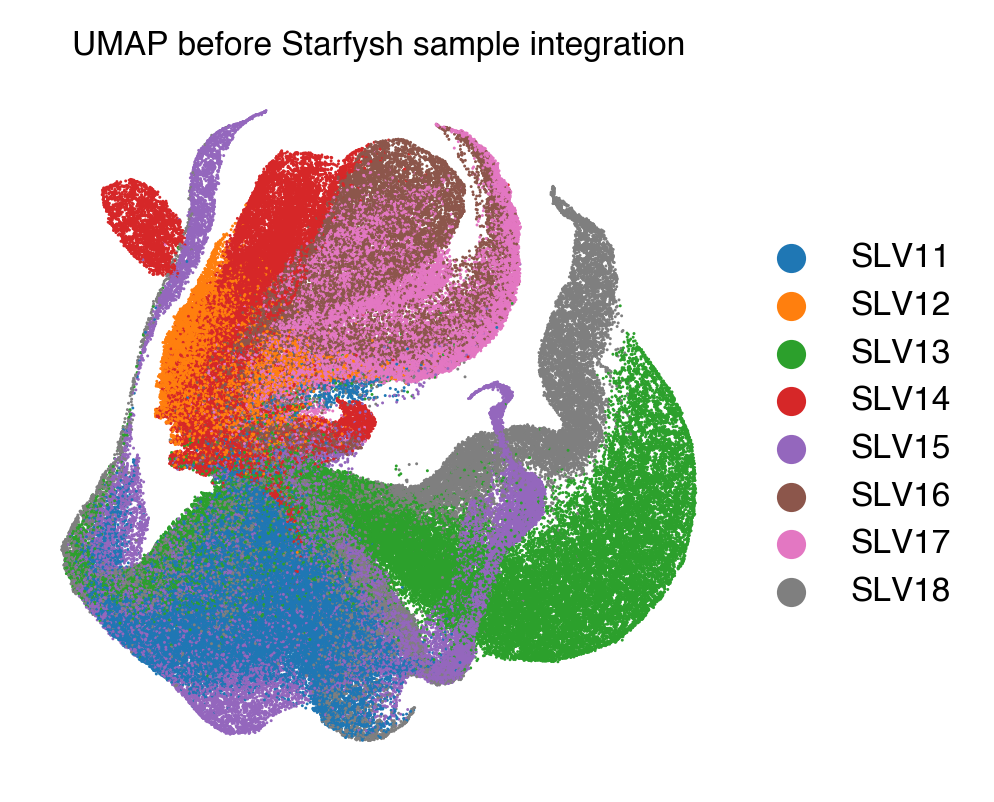

In [45]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 8, 'svg.fonttype': 'none'})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8
mpl.rcParams['ytick.labelsize'] = 8
meta = 'sample'
fig, ax = plt.subplots(1, 1, figsize=(3,3), dpi=300)
ax = sc.pl.umap(adata_all[np.random.permutation(len(adata_all))],color=meta,
                frameon=False, s=2, ax=ax,
                title='UMAP before Starfysh sample integration'
                )
for ext in ['pdf', 'png', 'svg']:
    fig.savefig(
        f'/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/spatial_figures/tissue_{meta}_integrated_all_umap_before_intergate.{ext}',
        bbox_inches='tight', 
        dpi=300)
plt.show()

In [25]:
# After integration
adata_integrate.obs[gene_sig.columns]=pd.DataFrame(adata_integrate.obsm['qc_m'],
                                                   columns=gene_sig.columns,
                                                   index=adata_integrate.obs_names)

In [26]:
#adata_sub = adata_integrate[adata_integrate.obs.index.isin(adata_sub.obs.index)]


In [27]:
adata_integrate

AnnData object with n_obs × n_vars = 232882 × 1133
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'patient', 'sample_type', 'grade', 'leiden', 'pheno_louvain', 'hub', 'Plasma cells', 'Myeloid', 'Fibroblast', 'B cells', 'NK cells', 'Instestinal_Epithelial cells', 'Enterocyte', 'Stomach_epithelial_cells', 'Stomach_stem_cells', 'Endothelial cell', 'Mast cell', 'CD8+ Effector T  cells', 'CD4+ Effector T cells', 'CD4+ Central Memory T cells', 'CD8+ Cytotoxic Unconventional T cells', 'CD8+ Proliferating T cells', 'CD4+ Regulatory T cells', 'CD8+ Homeostatic Unconventional T cells', 'CD8+ Tissue Resident Memory T cells', 'CD8+ Transitioning  Resident T cells', '

In [28]:
adata_integrate.obs[gene_sig.columns].sum(axis = 1)

s_016um_00258_00092-1-SLV11    1.0
s_016um_00245_00212-1-SLV11    1.0
s_016um_00283_00339-1-SLV11    1.0
s_016um_00191_00066-1-SLV11    1.0
s_016um_00244_00289-1-SLV11    1.0
                              ... 
s_016um_00173_00360-1-SLV18    1.0
s_016um_00196_00369-1-SLV18    1.0
s_016um_00206_00368-1-SLV18    1.0
s_016um_00185_00374-1-SLV18    1.0
s_016um_00361_00190-1-SLV18    1.0
Length: 232882, dtype: float32

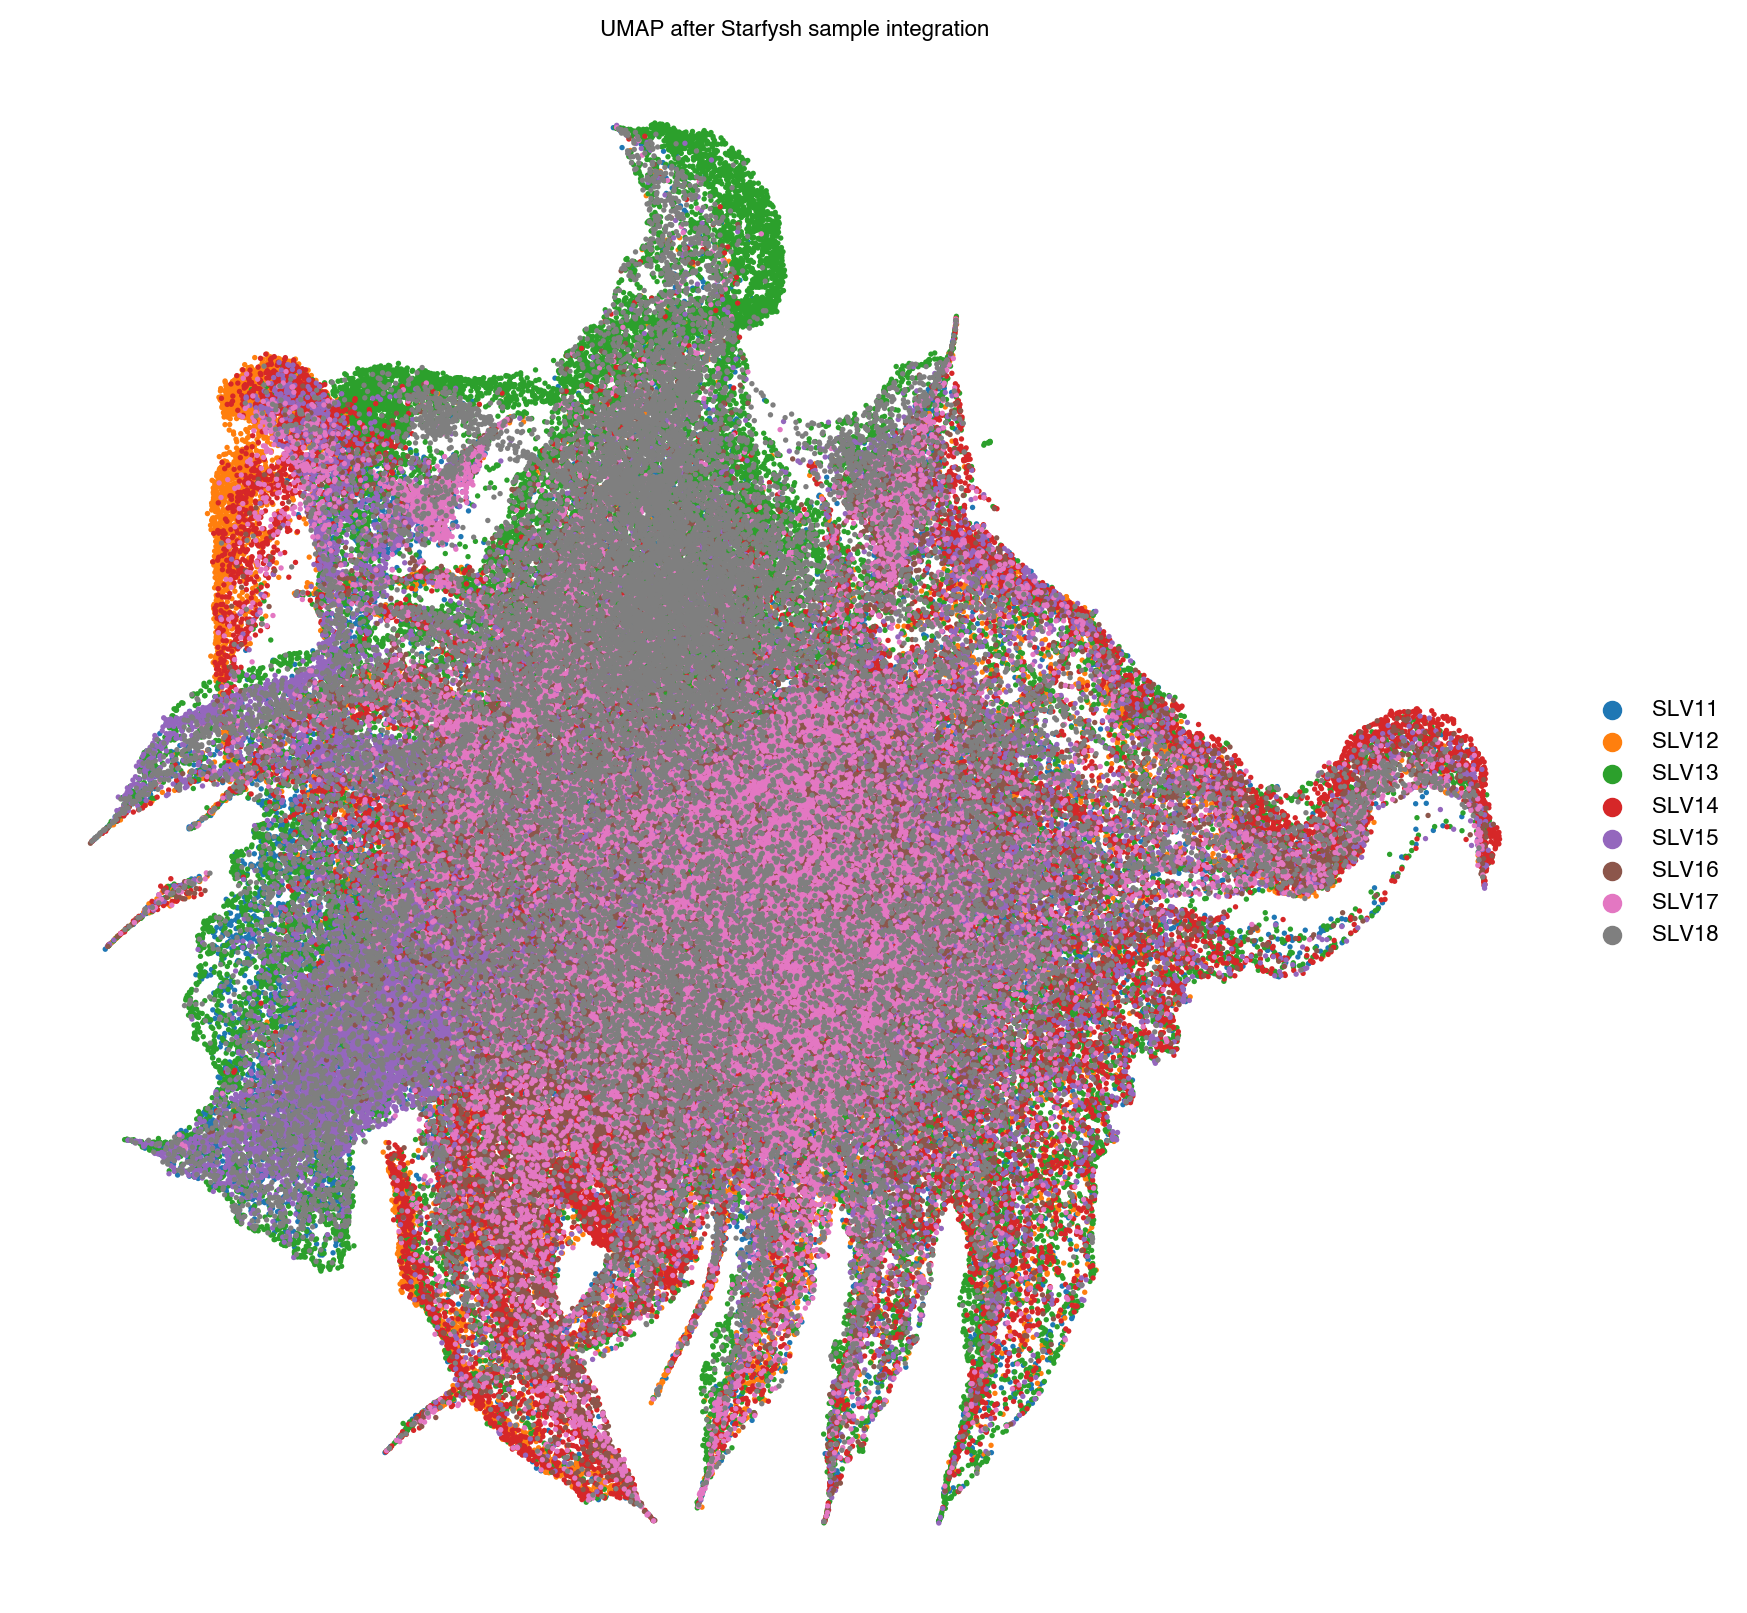

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10,10), dpi=200)
ax = sc.pl.umap(adata_integrate,color='sample',
                frameon=False, s=15, ax=ax,
                title='UMAP after Starfysh sample integration'
                )

plt.show()

##### It's observed that Starfysh's integration through learnt `qc` embedding space corrected for batch-effects introduced by different samples / tumor subtypes via joint deconvolution

In [30]:
adata_integrate

AnnData object with n_obs × n_vars = 232882 × 1133
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'patient', 'sample_type', 'grade', 'leiden', 'pheno_louvain', 'hub', 'Plasma cells', 'Myeloid', 'Fibroblast', 'B cells', 'NK cells', 'Instestinal_Epithelial cells', 'Enterocyte', 'Stomach_epithelial_cells', 'Stomach_stem_cells', 'Endothelial cell', 'Mast cell', 'CD8+ Effector T  cells', 'CD4+ Effector T cells', 'CD4+ Central Memory T cells', 'CD8+ Cytotoxic Unconventional T cells', 'CD8+ Proliferating T cells', 'CD4+ Regulatory T cells', 'CD8+ Homeostatic Unconventional T cells', 'CD8+ Tissue Resident Memory T cells', 'CD8+ Transitioning  Resident T cells', '

---